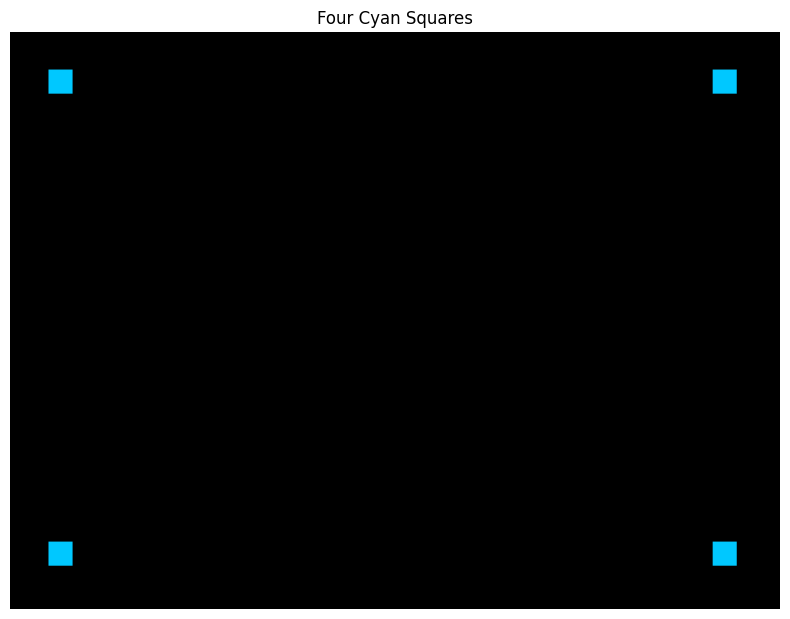

In [4]:
import pygame
import matplotlib.pyplot as plt
import numpy as np

# Initialize pygame
pygame.init()

# Create a surface (instead of a display window)
screen = pygame.Surface((800, 600))

# Fill the background with black
screen.fill((0, 0, 0))

# Define the Square class
class Square(pygame.sprite.Sprite):
    def __init__(self):
        super(Square, self).__init__()
        self.surf = pygame.Surface((25, 25))
        self.surf.fill((0, 200, 255))  # Cyan color
        self.rect = self.surf.get_rect()

# Instantiate all square objects
square1 = Square()
square2 = Square()
square3 = Square()
square4 = Square()

# Draw squares at the four corners
screen.blit(square1.surf, (40, 40))
screen.blit(square2.surf, (40, 530))
screen.blit(square3.surf, (730, 40))
screen.blit(square4.surf, (730, 530))

# Convert the pygame surface to a numpy array for matplotlib
pixel_array = pygame.surfarray.array3d(screen)

# Transpose because pygame and matplotlib have different axis conventions
pixel_array = np.transpose(pixel_array, (1, 0, 2))

# Display using matplotlib
plt.figure(figsize=(10, 7.5))
plt.imshow(pixel_array)
plt.axis('off')
plt.title('Four Cyan Squares')
plt.show()

# Quit pygame
pygame.quit()

In [5]:
import pygame
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from IPython.display import HTML

# Initialize pygame
pygame.init()

# Create surface (no display window needed in Colab)
win = pygame.Surface((500, 500))

# Font and colors
Font = pygame.font.SysFont('timesnewroman', 30)
white   = (255, 255, 255)
yellow  = (255, 255, 0)
green   = (0, 255, 255)
orange  = (255, 100, 0)

# Render letters
letter1 = Font.render("C", False, orange, yellow)
letter2 = Font.render("O", False, orange, green)
letter3 = Font.render("M", False, orange, yellow)
letter4 = Font.render("S", False, orange, green)
letter5 = Font.render("A", False, orange, yellow)
letter6 = Font.render("T", False, orange, green)
letter7 = Font.render("S", False, orange, yellow)

# State variables
i = 0
c = 1

def get_frame():
    global i, c

    if i >= 820:
        i = 0
        c += 1

    win.fill(white)

    if c % 6 == 0:
        win.blit(letter1, (662-i, -162+i))
        win.blit(letter2, (639-i, -139+i))
        win.blit(letter3, (608-i, -108+i))
        win.blit(letter4, (579-i, -79+i))
        win.blit(letter5, (552-i, -52+i))
        win.blit(letter6, (529-i, -29+i))
        win.blit(letter7, (500-i,   0+i))
        i += 80

    elif c % 6 == 5:
        win.blit(letter1, (-162+i, -162+i))
        win.blit(letter2, (-135+i, -135+i))
        win.blit(letter3, (-110+i, -110+i))
        win.blit(letter4, (-79+i,  -79+i))
        win.blit(letter5, (-52+i,  -52+i))
        win.blit(letter6, (-27+i,  -27+i))
        win.blit(letter7, (  0+i,    0+i))
        i += 80

    elif c % 6 == 4:
        win.blit(letter1, (480, -180+i))
        win.blit(letter2, (480, -150+i))
        win.blit(letter3, (480, -120+i))
        win.blit(letter4, (480,  -90+i))
        win.blit(letter5, (480,  -60+i))
        win.blit(letter6, (480,  -30+i))
        win.blit(letter7, (480,    0+i))
        i += 80

    elif c % 6 == 3:
        win.blit(letter1, (0, -180+i))
        win.blit(letter2, (0, -150+i))
        win.blit(letter3, (0, -120+i))
        win.blit(letter4, (0,  -90+i))
        win.blit(letter5, (0,  -60+i))
        win.blit(letter6, (0,  -30+i))
        win.blit(letter7, (0,    0+i))
        i += 80

    elif c % 6 == 1:
        win.blit(letter1, (-124+i, 0))
        win.blit(letter2, (-102+i, 0))
        win.blit(letter3,  (-82+i, 0))
        win.blit(letter4,  (-58+i, 0))
        win.blit(letter5,  (-40+i, 0))
        win.blit(letter6,  (-19+i, 0))
        win.blit(letter7,    (0+i, 0))
        i += 80

    elif c % 6 == 2:
        win.blit(letter1, (-124+i, 470))
        win.blit(letter2, (-102+i, 470))
        win.blit(letter3,  (-82+i, 470))
        win.blit(letter4,  (-58+i, 470))
        win.blit(letter5,  (-40+i, 470))
        win.blit(letter6,  (-19+i, 470))
        win.blit(letter7,    (0+i, 470))
        i += 80

    # Convert surface to numpy array
    frame = pygame.surfarray.array3d(win)
    frame = np.transpose(frame, (1, 0, 2))
    return frame

# ── Build animation ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
ax.axis('off')
plt.tight_layout()

img_display = ax.imshow(get_frame())

def update(frame_num):
    img_display.set_data(get_frame())
    return [img_display]

ani = animation.FuncAnimation(
    fig,
    update,
    frames=60,        # total frames to render
    interval=500,     # 500 ms between frames (matches original wait)
    blit=True
)

plt.close()  # Prevent static image from showing

# Display animation inline
HTML(ani.to_jshtml())

In [7]:
# Step 1: Upload your image
from google.colab import files
uploaded = files.upload()  # A button will appear — upload your image
# Step 2: Display it using pygame + matplotlib
import pygame
import matplotlib.pyplot as plt
import numpy as np

# Get the uploaded filename automatically
import os
image_filename = list(uploaded.keys())[0]

# Initialize pygame
pygame.init()

# Create surface
X, Y = 400, 400
white = (255, 255, 255)
display_surface = pygame.Surface((X, Y))

# Load the uploaded image
image = pygame.image.load(image_filename)

# Resize image to fit the surface if needed
image = pygame.transform.scale(image, (X, Y))

# Fill background and blit image
display_surface.fill(white)
display_surface.blit(image, (0, 0))

# Convert to numpy array for matplotlib
frame = pygame.surfarray.array3d(display_surface)
frame = np.transpose(frame, (1, 0, 2))

# Display using matplotlib
plt.figure(figsize=(5, 5))
plt.imshow(frame)
plt.axis('off')
plt.title('Image Display')
plt.show()

pygame.quit()
import pygame
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO

# Initialize pygame
pygame.init()

# Surface dimensions
X, Y = 400, 400
white = (255, 255, 255)
display_surface = pygame.Surface((X, Y))

# -------------------------------------------------------
# Replace this URL with any direct image URL you want
IMAGE_URL = "https://upload.wikimedia.org/wikipedia/commons/thumb/3/3a/Cat03.jpg/481px-Cat03.jpg"
# -------------------------------------------------------

# Download and load image
response = requests.get(IMAGE_URL)
image_data = BytesIO(response.content)
image = pygame.image.load(image_data)

# Resize to fit surface
image = pygame.transform.scale(image, (X, Y))

# Fill background and draw image
display_surface.fill(white)
display_surface.blit(image, (0, 0))

# Convert to numpy array
frame = pygame.surfarray.array3d(display_surface)
frame = np.transpose(frame, (1, 0, 2))

# Show with matplotlib
plt.figure(figsize=(5, 5))
plt.imshow(frame)
plt.axis('off')
plt.title('Image Display')
plt.show()

pygame.quit()


KeyboardInterrupt: 

In [8]:
import pygame
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
from IPython.display import HTML
import random

# ── Initialize ────────────────────────────────────────────────────
pygame.init()

# ── Constants ─────────────────────────────────────────────────────
WIDTH, HEIGHT = 600, 600
CELL          = 20
COLS          = WIDTH  // CELL
ROWS          = HEIGHT // CELL

# Colors
BLACK      = (0,   0,   0)
WHITE      = (255, 255, 255)
GREEN      = (0,   200,  0)
DARK_GREEN = (0,   150,  0)
RED        = (200,  0,   0)
YELLOW     = (255, 255,  0)
BLUE       = (0,   0,   200)
GRAY       = (100, 100, 100)
ORANGE     = (255, 165,  0)

# ── Game Surface ──────────────────────────────────────────────────
win = pygame.Surface((WIDTH, HEIGHT))
Font       = pygame.font.SysFont('arial', 22, bold=True)
Font_large = pygame.font.SysFont('arial', 38, bold=True)

# ── Helper: draw rounded rect ─────────────────────────────────────
def draw_rounded_rect(surf, color, rect, radius=8):
    pygame.draw.rect(surf, color, rect, border_radius=radius)

# ══════════════════════════════════════════════════════════════════
#  GAME STATE
# ══════════════════════════════════════════════════════════════════
def new_fruit(snake, obstacles, exclude=None):
    """Return a random cell not occupied by the snake, obstacles, or exclude."""
    occupied = set(map(tuple, snake)) | set(map(tuple, obstacles))
    if exclude:
        occupied.add(tuple(exclude))
    while True:
        pos = [random.randint(1, COLS-2), random.randint(1, ROWS-2)]
        if tuple(pos) not in occupied:
            return pos

def make_obstacles(snake, fruit):
    """Generate random wall-segment obstacles."""
    obs = []
    occupied = set(map(tuple, snake)) | {tuple(fruit)}
    attempts = 0
    while len(obs) < 8 and attempts < 500:
        attempts += 1
        x = random.randint(2, COLS-3)
        y = random.randint(2, ROWS-3)
        if (x, y) not in occupied:
            obs.append([x, y])
            occupied.add((x, y))
    return obs

# Initial state
snake     = [[COLS//2, ROWS//2],
             [COLS//2 - 1, ROWS//2],
             [COLS//2 - 2, ROWS//2]]
direction = [1, 0]
next_dir  = [1, 0]
score     = 0
speed     = 8          # frames per second equivalent (steps per second)
fruit     = new_fruit(snake, [])
yellow_fruit      = None   # appears when score > 150
obstacles         = []     # appear always (walls added from start for simplicity)
game_over         = False
game_over_surface = None

# ── Key state (simulate key presses via a queue) ──────────────────
dir_queue = []

# ══════════════════════════════════════════════════════════════════
#  DRAW FUNCTION
# ══════════════════════════════════════════════════════════════════
def draw_grid():
    for x in range(0, WIDTH, CELL):
        pygame.draw.line(win, (20, 20, 20), (x, 0), (x, HEIGHT))
    for y in range(0, HEIGHT, CELL):
        pygame.draw.line(win, (20, 20, 20), (0, y), (WIDTH, y))

def draw_state():
    win.fill(BLACK)
    draw_grid()

    # Border walls
    pygame.draw.rect(win, GRAY, (0, 0, WIDTH, CELL))
    pygame.draw.rect(win, GRAY, (0, HEIGHT-CELL, WIDTH, CELL))
    pygame.draw.rect(win, GRAY, (0, 0, CELL, HEIGHT))
    pygame.draw.rect(win, GRAY, (WIDTH-CELL, 0, CELL, HEIGHT))

    # Obstacles (Lab Task 2 - walls)
    for obs in obstacles:
        draw_rounded_rect(win, GRAY,
                          (obs[0]*CELL+2, obs[1]*CELL+2, CELL-4, CELL-4), 4)

    # Red fruit
    pygame.draw.ellipse(win, RED,
                        (fruit[0]*CELL+2, fruit[1]*CELL+2, CELL-4, CELL-4))

    # Yellow fruit (Lab Task 2 - score > 150)
    if yellow_fruit:
        pygame.draw.ellipse(win, YELLOW,
                            (yellow_fruit[0]*CELL+2,
                             yellow_fruit[1]*CELL+2, CELL-4, CELL-4))
        lbl = Font.render("x2", True, BLACK)
        win.blit(lbl, (yellow_fruit[0]*CELL+3, yellow_fruit[1]*CELL+3))

    # Snake body
    for idx, seg in enumerate(snake):
        color = GREEN if idx > 0 else DARK_GREEN
        draw_rounded_rect(win, color,
                          (seg[0]*CELL+1, seg[1]*CELL+1, CELL-2, CELL-2), 6)
        if idx == 0:                       # eyes on head
            ex = seg[0]*CELL + (14 if direction[0]==1 else 4 if direction[0]==-1 else 10)
            ey = seg[1]*CELL + (4  if direction[1]==1 else 14 if direction[1]==-1 else 7)
            pygame.draw.circle(win, WHITE, (ex, ey), 3)

    # Score bar
    score_txt = Font.render(f"Score: {score}", True, WHITE)
    speed_txt = Font.render(f"Speed: {'Fast' if speed>=16 else 'Normal'}", True, ORANGE)
    win.blit(score_txt, (CELL+4, 2))
    win.blit(speed_txt, (WIDTH//2 - 50, 2))

def draw_game_over():
    overlay = pygame.Surface((WIDTH, HEIGHT), pygame.SRCALPHA)
    overlay.fill((0, 0, 0, 180))
    win.blit(overlay, (0, 0))

    go  = Font_large.render("GAME  OVER", True, RED)
    sc  = Font.render(f"Final Score : {score}", True, WHITE)
    rst = Font.render("Close & re-run cell to restart", True, YELLOW)

    win.blit(go,  (WIDTH//2 - go.get_width()//2,  HEIGHT//2 - 70))
    win.blit(sc,  (WIDTH//2 - sc.get_width()//2,  HEIGHT//2 - 10))
    win.blit(rst, (WIDTH//2 - rst.get_width()//2, HEIGHT//2 + 40))

# ══════════════════════════════════════════════════════════════════
#  STEP FUNCTION  (one game tick)
# ══════════════════════════════════════════════════════════════════
def step():
    global snake, direction, next_dir, score, speed
    global fruit, yellow_fruit, obstacles, game_over

    if game_over:
        return

    # Apply queued direction change (prevent reversing)
    if dir_queue:
        nd = dir_queue.pop(0)
        if nd[0] != -direction[0] or nd[1] != -direction[1]:
            direction = nd

    head = [snake[0][0] + direction[0],
            snake[0][1] + direction[1]]

    # ── Collision: border wall ─────────────────────────────────────
    if head[0] <= 0 or head[0] >= COLS-1 or \
       head[1] <= 0 or head[1] >= ROWS-1:
        game_over = True
        return

    # ── Collision: self ────────────────────────────────────────────
    if head in snake:
        game_over = True
        return

    # ── Collision: obstacles ───────────────────────────────────────
    if head in obstacles:
        game_over = True
        return

    snake.insert(0, head)

    # ── Eat red fruit ──────────────────────────────────────────────
    if head == fruit:
        score += 10
        fruit = new_fruit(snake, obstacles,
                          exclude=yellow_fruit)

        # Lab Task 2a: speed doubles above 100
        if score > 100:
            speed = 16
        # Lab Task 2b: yellow fruit appears above 150
        if score > 150 and yellow_fruit is None:
            yellow_fruit = new_fruit(snake, obstacles, exclude=fruit)
        # Lab Task 2c: obstacles added above 50
        if score > 50 and len(obstacles) == 0:
            obstacles = make_obstacles(snake, fruit)
    else:
        snake.pop()

    # ── Eat yellow fruit ───────────────────────────────────────────
    if yellow_fruit and head == yellow_fruit:
        score += 20                        # double marks
        yellow_fruit = new_fruit(snake, obstacles, exclude=fruit)

# ══════════════════════════════════════════════════════════════════
#  BUILD ANIMATION
# ══════════════════════════════════════════════════════════════════
# Simulate arrow-key presses as a sequence so the snake moves
# automatically in Colab (no real keyboard).
# Pattern: go right → down → left → up → repeat
AUTO_DIRS = [
    [1, 0],   # right
    [0, 1],   # down
    [-1, 0],  # left
    [0, -1],  # up
]
auto_idx      = 0
auto_counter  = 0
AUTO_INTERVAL = 8   # change direction every N frames

TOTAL_FRAMES  = 300  # increase for a longer game replay

fig, ax = plt.subplots(figsize=(5, 5))
ax.axis('off')
plt.tight_layout(pad=0)

draw_state()
frame0 = np.transpose(pygame.surfarray.array3d(win), (1, 0, 2))
img_disp = ax.imshow(frame0)

def update(fn):
    global auto_idx, auto_counter

    if not game_over:
        # Auto-steer so snake moves visibly in Colab
        auto_counter += 1
        if auto_counter % AUTO_INTERVAL == 0:
            auto_idx = (auto_idx + 1) % len(AUTO_DIRS)
            dir_queue.append(AUTO_DIRS[auto_idx])

        step()

    draw_state()
    if game_over:
        draw_game_over()

    frame = np.transpose(pygame.surfarray.array3d(win), (1, 0, 2))
    img_disp.set_data(frame)
    return [img_disp]

ani = animation.FuncAnimation(
    fig, update,
    frames=TOTAL_FRAMES,
    interval=120,
    blit=True
)

plt.close()
HTML(ani.to_jshtml())